## Temporal Data Analysis for Workouts

In this notebook, we will perform the following temporal analyses on the processed workout data:

1. Identify impossible dates: Detect and handle dates like "31st April", "29th February" in non-leap years, or future dates.
2. Identify duplicate dates: Check if any workout entries are duplicated for the same date.
3. Identify inactivity periods: Find gaps where no workouts were recorded.
4. Analyze time trends: Analyze trends in the data over time (e.g., average pace by month/year).
5. Identify seasonal patterns: Explore any seasonal patterns in workout frequency or performance.
6. Make future predictions: Predict workout frequency or performance for the upcoming month.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os
os.chdir("C:/Users/Vale/Runalyze")
import utils
import importlib
importlib.reload(utils)

df = pd.read_csv("data/processed/processed_data.csv")
df.head(5)

,Workout ID,Date,Distance (km),Duration (min),Calories (kcal),Average Pace (min/km),Average Speed (km/h),Max Speed (km/h),Elevation Gain (m),Elevation Loss (m),Start Time,Temperature (C),Wind Speed (km/h),Humidity (%),Duration (sec),Average Pace (sec/km)
0,1,14/06/2023,4.37,20:00,316,04:35,13.1,18.1,13.0,13.0,19:11,22.0,11.0,80.0,1200,275
1,2,19/06/2023,4.45,20:00,315,04:29,13.3,15.5,12.0,13.0,20:06,29.0,14.0,53.0,1200,269
2,3,01/07/2023,5.26,25:01,395,04:45,12.6,15.1,12.0,14.0,12:09,22.0,8.0,79.0,1501,285
3,4,21/08/2023,4.03,20:02,312,04:58,12.1,14.3,0.0,10.0,19:03,34.0,8.0,42.0,1202,298
4,5,04/10/2023,3.76,20:01,305,05:19,11.3,13.6,9.0,13.0,17:03,25.0,13.0,68.0,1201,319


### Identify impossible dates

#### Future dates

In [6]:
# convert column 'Date' to pandas datetime object: invalid parsing will be set as NaT
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)

df.head(5)

,Workout ID,Date,Distance (km),Duration (min),Calories (kcal),Average Pace (min/km),Average Speed (km/h),Max Speed (km/h),Elevation Gain (m),Elevation Loss (m),Start Time,Temperature (C),Wind Speed (km/h),Humidity (%),Duration (sec),Average Pace (sec/km)
0,1,2023-06-14,4.37,20:00,316,04:35,13.1,18.1,13.0,13.0,19:11,22.0,11.0,80.0,1200,275
1,2,2023-06-19,4.45,20:00,315,04:29,13.3,15.5,12.0,13.0,20:06,29.0,14.0,53.0,1200,269
2,3,2023-07-01,5.26,25:01,395,04:45,12.6,15.1,12.0,14.0,12:09,22.0,8.0,79.0,1501,285
3,4,2023-08-21,4.03,20:02,312,04:58,12.1,14.3,0.0,10.0,19:03,34.0,8.0,42.0,1202,298
4,5,2023-10-04,3.76,20:01,305,05:19,11.3,13.6,9.0,13.0,17:03,25.0,13.0,68.0,1201,319


In [7]:
df.dtypes

Workout ID                        int64
Date                     datetime64[ns]
Distance (km)                   float64
Duration (min)                   object
Calories (kcal)                   int64
Average Pace (min/km)            object
Average Speed (km/h)            float64
Max Speed (km/h)                float64
Elevation Gain (m)              float64
Elevation Loss (m)              float64
Start Time                       object
Temperature (C)                 float64
Wind Speed (km/h)               float64
Humidity (%)                    float64
Duration (sec)                    int64
Average Pace (sec/km)             int64
dtype: object

In [8]:
from datetime import datetime

pd_today = pd.to_datetime(datetime.today(), format="%Y/%m/%d")
pd_today

Timestamp('2024-12-06 10:52:24.228803')

In [9]:
future_dates = df[df['Date'] > pd_today]

In [10]:
if not future_dates.empty:
    print(f"Found {len(future_dates)} future date(s).")
else:
    print("No future dates found.")

No future dates found.


#### Invalid dates (e.g., 30th February)

In [11]:
invalid_dates = df[df['Date'].isna()]

if not invalid_dates.empty:
    print(f"Found {len(invalid_dates)} invalid date(s).")
else:
    print("No invalid dates found.")

No invalid dates found.


### Identify Duplicate Dates

In [12]:
duplicated_dates = df[df.duplicated(subset=['Date'], keep=False)]
duplicated_dates_list = []

for idx, row in duplicated_dates.iterrows():
    if not row['Date'] in duplicated_dates_list:
        duplicated_dates_list.append(row['Date'])
        
print("You performed a repeat workout on the following dates: \n")
print("------------------------------------------------------\n")
for date in duplicated_dates_list:
    print(str(date).split(" ")[0] + '\n')

You performed a repeat workout on the following dates: 

------------------------------------------------------

2024-11-02

2024-11-23



### Identify Inactivity Periods

In [13]:
df = df.sort_values(by='Date')

In [14]:
df['Date Difference'] = df['Date'].diff().dt.days
df.head()

,Workout ID,Date,Distance (km),Duration (min),Calories (kcal),Average Pace (min/km),Average Speed (km/h),Max Speed (km/h),Elevation Gain (m),Elevation Loss (m),Start Time,Temperature (C),Wind Speed (km/h),Humidity (%),Duration (sec),Average Pace (sec/km),Date Difference
0,1,2023-06-14,4.37,20:00,316,04:35,13.1,18.1,13.0,13.0,19:11,22.0,11.0,80.0,1200,275,NaN
1,2,2023-06-19,4.45,20:00,315,04:29,13.3,15.5,12.0,13.0,20:06,29.0,14.0,53.0,1200,269,5.0
2,3,2023-07-01,5.26,25:01,395,04:45,12.6,15.1,12.0,14.0,12:09,22.0,8.0,79.0,1501,285,12.0
3,4,2023-08-21,4.03,20:02,312,04:58,12.1,14.3,0.0,10.0,19:03,34.0,8.0,42.0,1202,298,51.0
4,5,2023-10-04,3.76,20:01,305,05:19,11.3,13.6,9.0,13.0,17:03,25.0,13.0,68.0,1201,319,44.0


In [15]:
threshold = 7

inactivity_periods = df[df['Date Difference'] > threshold]
inactivity_periods

,Workout ID,Date,Distance (km),Duration (min),Calories (kcal),Average Pace (min/km),Average Speed (km/h),Max Speed (km/h),Elevation Gain (m),Elevation Loss (m),Start Time,Temperature (C),Wind Speed (km/h),Humidity (%),Duration (sec),Average Pace (sec/km),Date Difference
2,3,2023-07-01,5.26,25:01,395,04:45,12.6,15.1,12.0,14.0,12:09,22.0,8.0,79.0,1501,285,12.0
3,4,2023-08-21,4.03,20:02,312,04:58,12.1,14.3,0.0,10.0,19:03,34.0,8.0,42.0,1202,298,51.0
4,5,2023-10-04,3.76,20:01,305,05:19,11.3,13.6,9.0,13.0,17:03,25.0,13.0,68.0,1201,319,44.0
8,9,2023-11-01,3.00,15:02,237,05:00,12.0,14.4,12.0,9.0,14:48,14.0,8.0,96.0,902,300,13.0
9,10,2024-01-08,3.69,20:00,305,05:25,11.1,16.4,0.0,7.0,16:24,8.0,14.0,88.0,1200,325,68.0
19,20,2024-04-03,3.10,16:01,243,05:10,11.6,14.1,6.0,12.0,15:19,18.0,11.0,49.0,961,310,60.0
20,21,2024-08-10,5.02,23:13,366,04:37,13.0,14.6,5.0,18.0,08:30,26.0,6.0,67.0,1393,277,129.0
21,22,2024-09-15,1.68,06:02,91,03:35,16.7,21.0,0.0,10.0,11:09,19.0,11.0,49.0,362,215,36.0
30,31,2024-10-30,8.00,35:52,645,04:28,13.4,14.7,19.0,29.0,15.23,21.0,8.0,74.0,2152,268,13.0


In [16]:
inactivities = []

for idx, row in inactivity_periods.iterrows():
    current_id = row['Workout ID']
    
    previous_id = current_id - 1
    
    previous_wk = df[df["Workout ID"] == previous_id]
    
    start_date = previous_wk.iloc[0, 1].strftime('%Y-%m-%d')
    end_date = row['Date']
    duration = row['Date Difference']
    
    inactivities.append({
        'Start Date': start_date,
        'End Date': end_date,
        'Duration (days)': duration
    })
    
inactivity_df = pd.DataFrame(inactivities)
inactivity_df

,Start Date,End Date,Duration (days)
0,2023-06-19,2023-07-01,12.0
1,2023-07-01,2023-08-21,51.0
2,2023-08-21,2023-10-04,44.0
3,2023-10-19,2023-11-01,13.0
4,2023-11-01,2024-01-08,68.0
5,2024-02-03,2024-04-03,60.0
6,2024-04-03,2024-08-10,129.0
7,2024-08-10,2024-09-15,36.0
8,2024-10-17,2024-10-30,13.0


In [17]:
inactivity_df.dtypes

Start Date                 object
End Date           datetime64[ns]
Duration (days)           float64
dtype: object

In [18]:
inactivity_df['Start Date'] = pd.to_datetime(inactivity_df['Start Date'])
inactivity_df.dtypes

Start Date         datetime64[ns]
End Date           datetime64[ns]
Duration (days)           float64
dtype: object

Text(0, 0.5, 'Inactivty Periods')

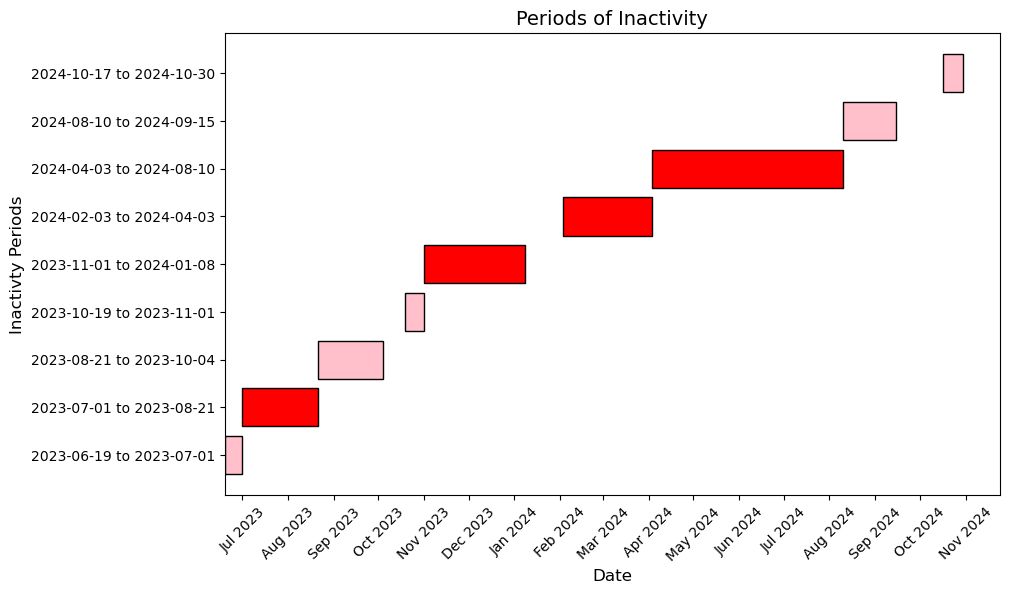

In [19]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10, 6))

for i, row in inactivity_df.iterrows():
    ax.barh(
        i, 
        row['Duration (days)'], 
        left=row['Start Date'], 
        color='red' if row['Duration (days)'] > 50 else 'pink', 
        edgecolor='black', 
        height=0.8
    )
    
ax.set_yticks(range(0, inactivity_df.index[-1]+1))
ax.set_yticklabels([f"{row['Start Date'].strftime('%Y-%m-%d')} to {row['End Date'].strftime('%Y-%m-%d')}"
                   for _, row in inactivity_df.iterrows()])

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)

ax.set_title('Periods of Inactivity', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Inactivty Periods', fontsize=12)

#### Monthly Workout Analysis

Analyzing the number of workouts per month and identifying inactive months.

In [20]:
df_without_duplicates = df.drop_duplicates(subset=['Date'], keep='first')

monthly_wks = df_without_duplicates.groupby(df_without_duplicates['Date'].dt.to_period('M')).size()
monthly_wks

Date
2023-06    2
2023-07    1
2023-08    1
2023-10    4
2023-11    1
2024-01    9
2024-02    1
2024-04    1
2024-08    1
2024-09    5
2024-10    5
2024-11    8
Freq: M, dtype: int64

In [21]:
start_date = (df_without_duplicates.iloc[0].Date).strftime('%Y-%m')
end_date = (df_without_duplicates.iloc[-1].Date).strftime('%Y-%m')

time_interval = f"{start_date} --> {end_date}"
print(time_interval)

2023-06 --> 2024-11


In [22]:
all_months = pd.date_range(start=start_date, end=end_date, freq='MS').to_period('M')

missing_months = all_months[~all_months.isin(monthly_wks.index)]
missing_months

PeriodIndex(['2023-09', '2023-12', '2024-03', '2024-05', '2024-06', '2024-07'], dtype='period[M]')

In [23]:
inactive_month_dict = {month: 0 for month in missing_months}

inactive_month_series = pd.Series(inactive_month_dict)
inactive_month_series

2023-09    0
2023-12    0
2024-03    0
2024-05    0
2024-06    0
2024-07    0
Freq: M, dtype: int64

In [24]:
wks_per_month = pd.concat([monthly_wks, inactive_month_series])
wks_per_month = wks_per_month.sort_index()
wks_per_month

2023-06    2
2023-07    1
2023-08    1
2023-09    0
2023-10    4
2023-11    1
2023-12    0
2024-01    9
2024-02    1
2024-03    0
2024-04    1
2024-05    0
2024-06    0
2024-07    0
2024-08    1
2024-09    5
2024-10    5
2024-11    8
Freq: M, dtype: int64

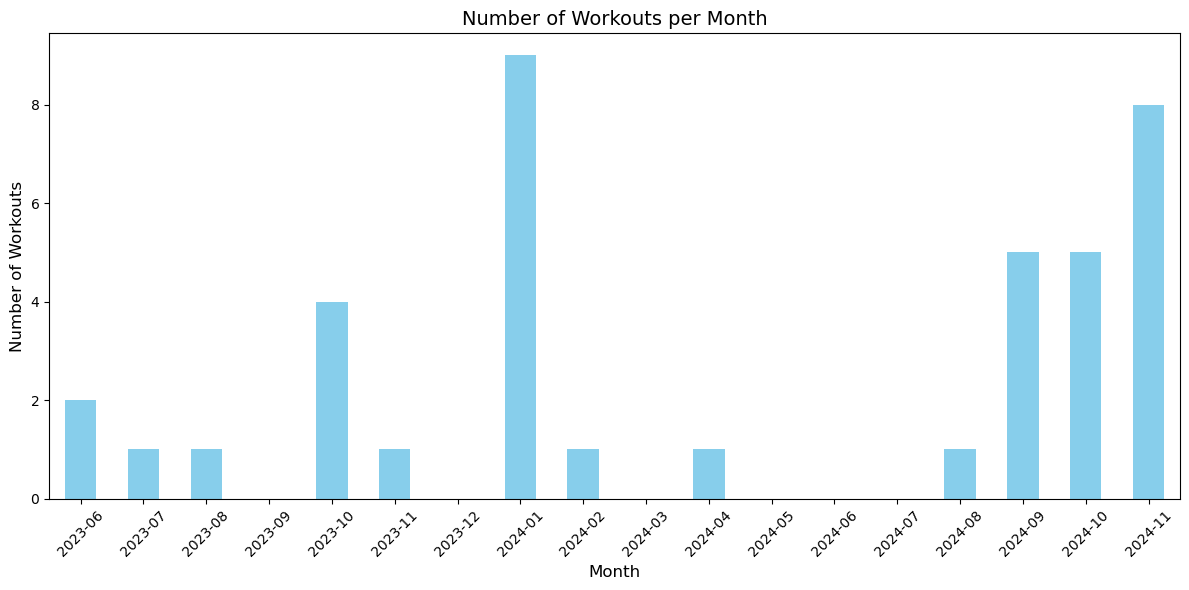

In [25]:
plt.figure(figsize=(12, 6))
wks_per_month.plot(kind='bar', color='skyblue')

plt.title('Number of Workouts per Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Workouts', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

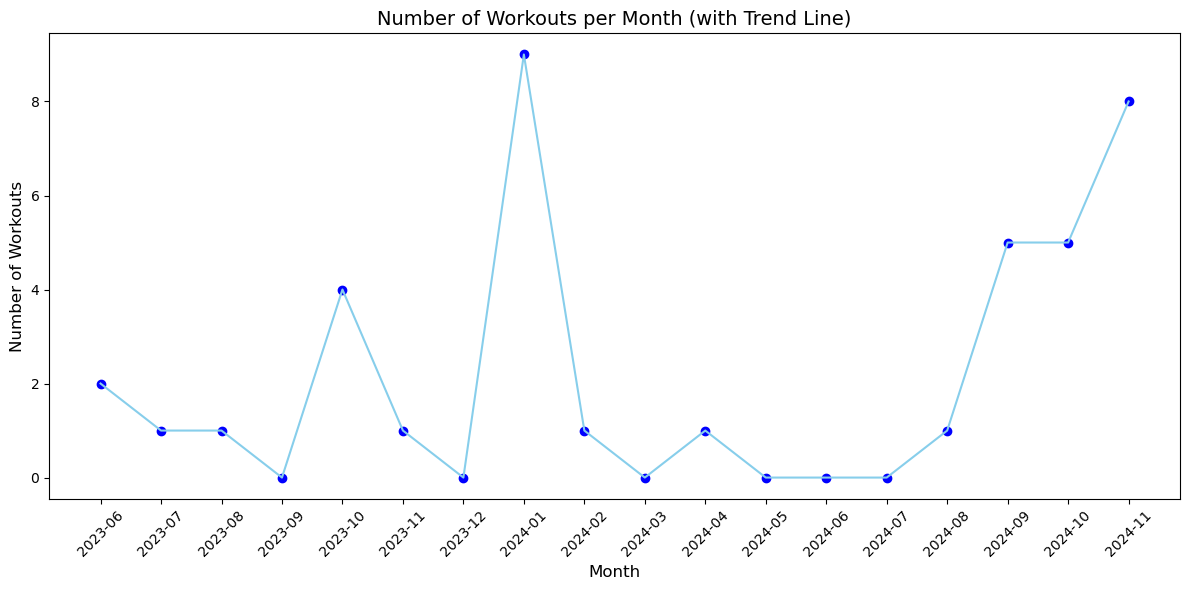

In [26]:
plt.figure(figsize=(12,6))

plt.scatter(wks_per_month.index.astype(str), wks_per_month.values, color='blue')
plt.plot(wks_per_month.index.astype(str), wks_per_month.values, color='skyblue')

plt.title('Number of Workouts per Month (with Trend Line)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Workouts', fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Analyze Time Trends

Analyze time trends by calculating monthly, annual, or weekly averages of key metrics like pace.

The weighted average pace accounts for distance, ensuring longer workouts influence the pace more than shorter ones.

**Formula:**  
$$
\text{Weighted Avg Pace} = \frac{\sum (\text{Pace} \times \text{Distance})}{\sum (\text{Distance})}
$$

In [27]:
df['Year'] = df['Date'].dt.year

df.head(5)

,Workout ID,Date,Distance (km),Duration (min),Calories (kcal),Average Pace (min/km),Average Speed (km/h),Max Speed (km/h),Elevation Gain (m),Elevation Loss (m),Start Time,Temperature (C),Wind Speed (km/h),Humidity (%),Duration (sec),Average Pace (sec/km),Date Difference,Year
0,1,2023-06-14,4.37,20:00,316,04:35,13.1,18.1,13.0,13.0,19:11,22.0,11.0,80.0,1200,275,NaN,2023
1,2,2023-06-19,4.45,20:00,315,04:29,13.3,15.5,12.0,13.0,20:06,29.0,14.0,53.0,1200,269,5.0,2023
2,3,2023-07-01,5.26,25:01,395,04:45,12.6,15.1,12.0,14.0,12:09,22.0,8.0,79.0,1501,285,12.0,2023
3,4,2023-08-21,4.03,20:02,312,04:58,12.1,14.3,0.0,10.0,19:03,34.0,8.0,42.0,1202,298,51.0,2023
4,5,2023-10-04,3.76,20:01,305,05:19,11.3,13.6,9.0,13.0,17:03,25.0,13.0,68.0,1201,319,44.0,2023


In [28]:
annual_weighted_avg_pace = df.groupby('Year').apply(
    lambda group: (group['Average Pace (sec/km)'] * group['Distance (km)']).sum() / group['Distance (km)'].sum()
)

annual_weighted_avg_pace

Year
2023    287.024768
2024    263.517125
dtype: float64

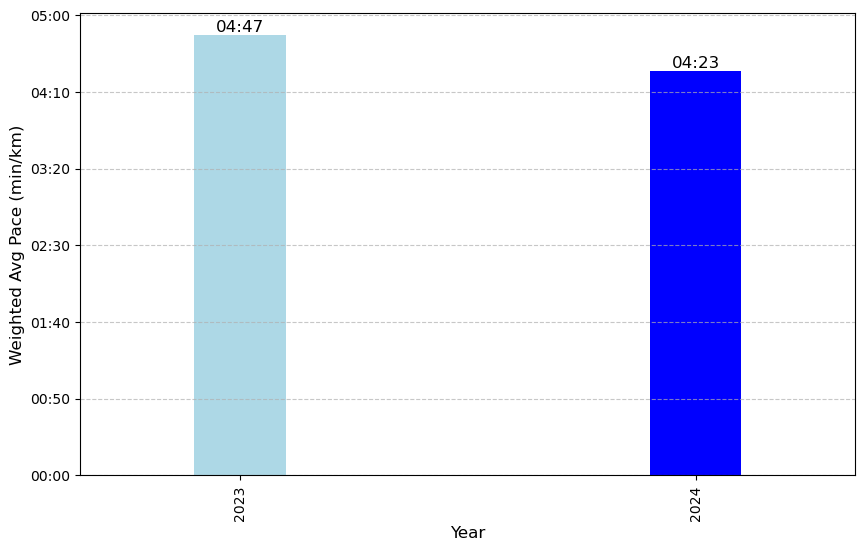

In [29]:
from matplotlib.ticker import FuncFormatter
from utils.data_processing import seconds_to_minutes

def format_y_ticks(seconds, pos):
    return seconds_to_minutes(int(seconds))

plt.figure(figsize=(10, 6))

colors=['lightblue', 'blue']

ax = annual_weighted_avg_pace.plot(kind='bar', color=colors, width=0.2)

for i, v in enumerate(annual_weighted_avg_pace):    
    ax.text(i, v + 0.1, f'{seconds_to_minutes(int(v))}', ha='center', va='bottom', fontsize=12)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Weighted Avg Pace (min/km)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.gca().yaxis.set_major_formatter(FuncFormatter(format_y_ticks))

plt.show()

Calculating weekly average pace (sec/km)

In [30]:
weekly_avg_pace = df.groupby(df['Date'].dt.to_period('W'))['Average Pace (sec/km)'].mean()
weekly_avg_pace.head()

Date
2023-06-12/2023-06-18    275.0
2023-06-19/2023-06-25    269.0
2023-06-26/2023-07-02    285.0
2023-08-21/2023-08-27    298.0
2023-10-02/2023-10-08    307.5
Freq: W-SUN, Name: Average Pace (sec/km), dtype: float64

In [31]:
weekly_weighted_avg_pace = df.groupby(df['Date'].dt.to_period('W'))
weekly_weighted_avg_pace = weekly_weighted_avg_pace.apply(
    lambda group: (group['Average Pace (sec/km)'] * group['Distance (km)']).sum() / group['Distance (km)'].sum()
)

weekly_weighted_avg_pace

Date
2023-06-12/2023-06-18    275.000000
2023-06-19/2023-06-25    269.000000
2023-06-26/2023-07-02    285.000000
2023-08-21/2023-08-27    298.000000
2023-10-02/2023-10-08    307.072983
2023-10-09/2023-10-15    276.000000
2023-10-16/2023-10-22    269.000000
2023-10-30/2023-11-05    300.000000
2024-01-08/2024-01-14    300.489982
2024-01-15/2024-01-21    282.108787
2024-01-22/2024-01-28    280.641186
2024-01-29/2024-02-04    266.306306
2024-04-01/2024-04-07    310.000000
2024-08-05/2024-08-11    277.000000
2024-09-09/2024-09-15    215.000000
2024-09-16/2024-09-22    261.857143
2024-09-23/2024-09-29    249.000000
2024-09-30/2024-10-06    245.983573
2024-10-07/2024-10-13    248.985432
2024-10-14/2024-10-20    245.000000
2024-10-28/2024-11-03    251.323642
2024-11-04/2024-11-10    276.601864
2024-11-11/2024-11-17    238.874065
2024-11-18/2024-11-24    245.343081
2024-11-25/2024-12-01    242.000000
Freq: W-SUN, dtype: float64

In [32]:
weekly_weighted_avg_pace.index = weekly_weighted_avg_pace.index.start_time
weekly_weighted_avg_pace.index

DatetimeIndex(['2023-06-12', '2023-06-19', '2023-06-26', '2023-08-21',
               '2023-10-02', '2023-10-09', '2023-10-16', '2023-10-30',
               '2024-01-08', '2024-01-15', '2024-01-22', '2024-01-29',
               '2024-04-01', '2024-08-05', '2024-09-09', '2024-09-16',
               '2024-09-23', '2024-09-30', '2024-10-07', '2024-10-14',
               '2024-10-28', '2024-11-04', '2024-11-11', '2024-11-18',
               '2024-11-25'],
              dtype='datetime64[ns]', name='Date', freq=None)

In [33]:
full_range = pd.date_range(
    start=weekly_weighted_avg_pace.index.min(),
    end=weekly_weighted_avg_pace.index.max(),
    freq='W-MON'
)

full_range

DatetimeIndex(['2023-06-12', '2023-06-19', '2023-06-26', '2023-07-03',
               '2023-07-10', '2023-07-17', '2023-07-24', '2023-07-31',
               '2023-08-07', '2023-08-14', '2023-08-21', '2023-08-28',
               '2023-09-04', '2023-09-11', '2023-09-18', '2023-09-25',
               '2023-10-02', '2023-10-09', '2023-10-16', '2023-10-23',
               '2023-10-30', '2023-11-06', '2023-11-13', '2023-11-20',
               '2023-11-27', '2023-12-04', '2023-12-11', '2023-12-18',
               '2023-12-25', '2024-01-01', '2024-01-08', '2024-01-15',
               '2024-01-22', '2024-01-29', '2024-02-05', '2024-02-12',
               '2024-02-19', '2024-02-26', '2024-03-04', '2024-03-11',
               '2024-03-18', '2024-03-25', '2024-04-01', '2024-04-08',
               '2024-04-15', '2024-04-22', '2024-04-29', '2024-05-06',
               '2024-05-13', '2024-05-20', '2024-05-27', '2024-06-03',
               '2024-06-10', '2024-06-17', '2024-06-24', '2024-07-01',
      

In [34]:
aligned_data = weekly_weighted_avg_pace.reindex(full_range, fill_value=0)

print("First 5 rows: \n")
print("-------------\n")

for idx, v in aligned_data.head(5).items():
    print(f"{(str(idx).split(' ')[0])} --> {v}")

First 5 rows: 

-------------

2023-06-12 --> 275.0
2023-06-19 --> 269.0
2023-06-26 --> 285.0
2023-07-03 --> 0.0
2023-07-10 --> 0.0


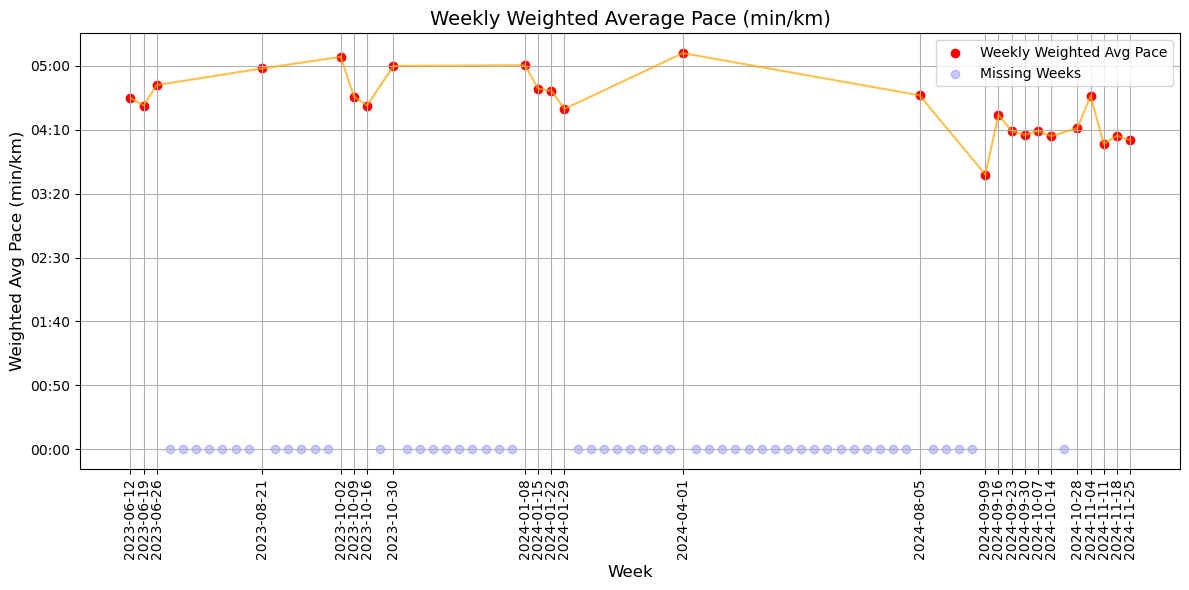

In [35]:
filtered_data = aligned_data[aligned_data > 0]
missing_weeks = aligned_data[aligned_data == 0]

plt.figure(figsize=(12,6))

plt.scatter(
    filtered_data.index,
    filtered_data.values,
    color='red',
    label='Weekly Weighted Avg Pace'
)

plt.plot(filtered_data.index, filtered_data.values, color='orange', alpha=0.7)
plt.scatter(missing_weeks.index, missing_weeks.values, color='blue', alpha=0.2, label='Missing Weeks')

plt.title('Weekly Weighted Average Pace (min/km)', fontsize=14)
plt.xlabel('Week', fontsize=12)
plt.ylabel('Weighted Avg Pace (min/km)', fontsize=12)
plt.xticks(aligned_data[aligned_data > 0].index, rotation=90)
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_y_ticks))
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

#### Identify the Best Performance Week (Lowest Average Pace)

In [36]:
from utils.data_processing import seconds_to_minutes

best_week_pace = filtered_data.min()

best_week = filtered_data[filtered_data == best_week_pace].index[0]

best_week_pace = seconds_to_minutes(best_week_pace)

print(f"The best performance was in the week starting on {best_week.strftime('%Y-%m-%d')} with an average pace of {best_week_pace} min/km.")

The best performance was in the week starting on 2024-09-09 with an average pace of 03:35 min/km.


### Identify seasonal patterns: Explore any seasonal patterns in workout frequency or performance.

Get the number of workouts per season.

In [37]:
from utils.data_processing import get_season

df['Season'] = df['Date'].apply(get_season)

df.head(5)

,Workout ID,Date,Distance (km),Duration (min),Calories (kcal),Average Pace (min/km),Average Speed (km/h),Max Speed (km/h),Elevation Gain (m),Elevation Loss (m),Start Time,Temperature (C),Wind Speed (km/h),Humidity (%),Duration (sec),Average Pace (sec/km),Date Difference,Year,Season
0,1,2023-06-14,4.37,20:00,316,04:35,13.1,18.1,13.0,13.0,19:11,22.0,11.0,80.0,1200,275,NaN,2023,Summer
1,2,2023-06-19,4.45,20:00,315,04:29,13.3,15.5,12.0,13.0,20:06,29.0,14.0,53.0,1200,269,5.0,2023,Summer
2,3,2023-07-01,5.26,25:01,395,04:45,12.6,15.1,12.0,14.0,12:09,22.0,8.0,79.0,1501,285,12.0,2023,Summer
3,4,2023-08-21,4.03,20:02,312,04:58,12.1,14.3,0.0,10.0,19:03,34.0,8.0,42.0,1202,298,51.0,2023,Summer
4,5,2023-10-04,3.76,20:01,305,05:19,11.3,13.6,9.0,13.0,17:03,25.0,13.0,68.0,1201,319,44.0,2023,Autumn


In [38]:
workouts_per_season = df.drop_duplicates(subset='Date', keep='first')['Season'].value_counts()
workouts_per_season

Season
Autumn    23
Winter    10
Summer     5
Spring     1
Name: count, dtype: int64

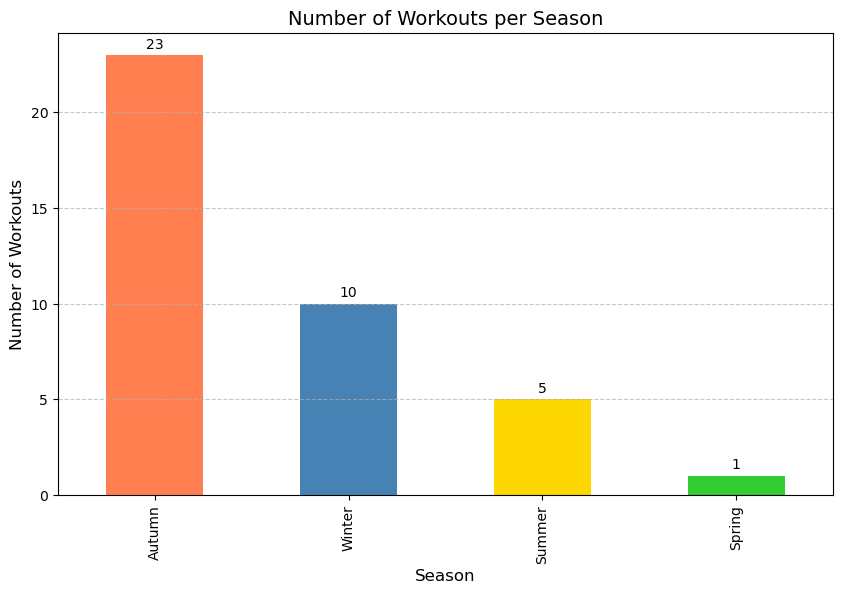

In [39]:
plt.figure(figsize=(10, 6))

ax = workouts_per_season.plot(kind='bar', color=['#FF7F50', '#4682B4', '#FFD700', '#32CD32'])

plt.title('Number of Workouts per Season', fontsize=14)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Number of Workouts', fontsize=12)

for i, v in enumerate(workouts_per_season):
    ax.text(i, v + 0.2, str(v), ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()